In [45]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, hamming_loss,confusion_matrix

In [ ]:
## Data is stored in the cache for ease of access / disposal
yt_path= kagglehub.dataset_download("bsthere/youtube-trending-videos-stats-2026")

print("Path to YouTube dataset files:", yt_path)

Path to YouTube dataset files: C:\Users\sheic\.cache\kagglehub\datasets\bsthere\youtube-trending-videos-stats-2026\versions\3


In [ ]:
## Import US YouTube Data
yt_df = pd.read_csv(yt_path + "/US_trending.csv")

print(yt_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 16400 entries, 0 to 16399
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       16400 non-null  str  
 1   trending_date  16400 non-null  str  
 2   title          16400 non-null  str  
 3   channel_title  16399 non-null  str  
 4   views          16400 non-null  int64
 5   likes          16400 non-null  int64
 6   dislikes       16400 non-null  int64
 7   publish_time   16400 non-null  str  
 8   category_id    16400 non-null  int64
 9   tags           16400 non-null  str  
 10  comments       16400 non-null  int64
 11  channel_id     16400 non-null  str  
 12  description    13580 non-null  str  
dtypes: int64(5), str(8)
memory usage: 1.6 MB
None


In [ ]:
## Identifying maximum values
print("Maximum Likes: ")
print(yt_df.iloc[yt_df['likes'].idxmax()])

print("\n Maximum Dislikes: ")
print(yt_df.iloc[yt_df['dislikes'].idxmax()])

print("\n Maximum Comments: ")
print(yt_df.iloc[yt_df['comments'].idxmax()])

print("\n Maximum Views: ")
print(yt_df.iloc[yt_df['views'].idxmax()])

## Note maximum dislikes is 0, likely because YouTube hides dislikes these days.


Maximum Likes: 
video_id                                               HyHNuVaZJ-k
trending_date                                             26.26.02
title                   Gorillaz - Feel Good Inc. (Official Video)
channel_title                                             Gorillaz
views                                                   1105355210
likes                                                      8968014
dislikes                                                         0
publish_time                                  2016-06-28T12:53:12Z
category_id                                                     10
tags             gorillaz|Feel Good Inc.|Feel Good Inc|feel|goo...
comments                                                    232241
channel_id                                UCfIXdjDQH9Fau7y99_Orpjw
description      Official HD Video for Gorillaz' fantastic trac...
Name: 6704, dtype: object

 Maximum Dislikes: 
video_id                                               5Q_sCOFwC5g

In [ ]:
## Identifying maximum values
print("Minimum Likes: ")
print(yt_df.iloc[yt_df['likes'].idxmin()])

print("\nMinimum Dislikes: ")
print(yt_df.iloc[yt_df['dislikes'].idxmin()])

print("\nMinimum Comments: ")
print(yt_df.iloc[yt_df['comments'].idxmin()])

print("\nMinimum Views: ")
print(yt_df.iloc[yt_df['views'].idxmin()])

## Note outlier values: videos posted at the time the data was pulled

Minimum Likes: 
video_id                                               mlH_7dkZMrc
trending_date                                             26.26.02
title               The State of the Union and Democratic Response
channel_title                                                  CNN
views                                                            0
likes                                                            0
dislikes                                                         0
publish_time                                  2026-02-25T13:50:58Z
category_id                                                     24
tags                                                        [none]
comments                                                         0
channel_id                                UCStfhR2V58QkCCyq_8dlk6g
description      President Donald Trump delivers the State of t...
Name: 14, dtype: object

Minimum Dislikes: 
video_id                                               5Q_sCOFwC5g
tr

In [28]:
# Likes Qualities
print("*** Likes ***")
print("Max: ", yt_df['likes'].max())
print("Mean: ", np.mean(yt_df['likes']))
print("Median: ", np.median(yt_df['likes']))
print("Variance: ", np.var(yt_df['likes']))
print("Standard distribution: ", np.std(yt_df['likes']))


*** Likes ***
Max:  8968014
Mean:  42664.4975
Median:  6225.5
Variance:  23839562074.79109
Standard distribution:  154400.6543858901


25244.0 925.0 24319.0
61710


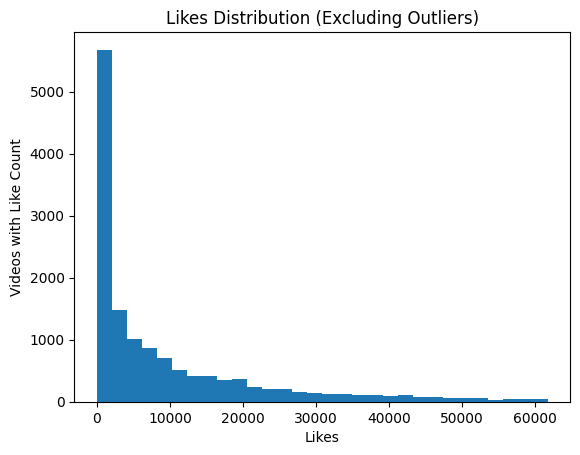

In [39]:
# Likes distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['likes'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['likes'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['likes'] > (q25 - iqr*1.5)]

print(no_outliers['likes'].max())

plt.hist(no_outliers['likes'], bins=30)
plt.title("Likes Distribution (Excluding Outliers)")
plt.ylabel("Videos with Like Count")
plt.xlabel("Likes")
plt.show()

In [38]:
# Comments Qualities
print("*** Comments ***")
print("Max: ", yt_df['comments'].max())
print("Mean: ", np.mean(yt_df['comments']))
print("Median: ", np.median(yt_df['comments']))
print("Variance: ", np.var(yt_df['comments']))
print("Standard distribution: ", np.std(yt_df['comments']))

*** Comments ***
Max:  451909
Mean:  1438.0951219512194
Median:  256.0
Variance:  44582388.866195716
Standard distribution:  6677.004483014499


946.0 34.0 912.0
2313


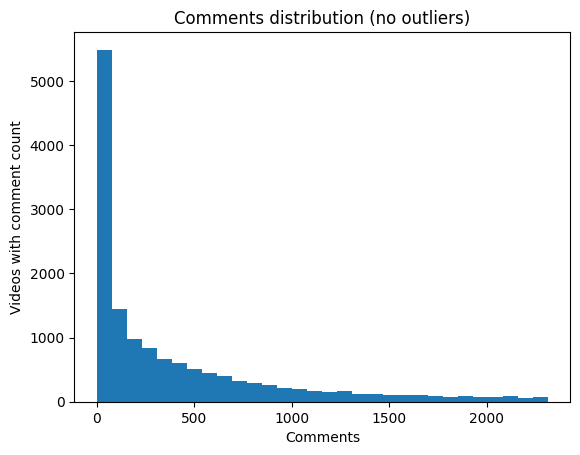

In [40]:
# Likes distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['comments'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['comments'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['comments'] > (q25 - iqr*1.5)]

print(no_outliers['comments'].max())

plt.hist(no_outliers['comments'], bins=30)
plt.title("Comments distribution (no outliers)")
plt.ylabel("Videos with comment count")
plt.xlabel("Comments")
plt.show()

In [41]:
# Comments Qualities
print("*** Views ***")
print("Max: ", yt_df['views'].max())
print("Mean: ", np.mean(yt_df['views']))
print("Median: ", np.median(yt_df['views']))
print("Variance: ", np.var(yt_df['views']))
print("Standard distribution: ", np.std(yt_df['views']))

*** Views ***
Max:  1105355210
Mean:  1742672.993597561
Median:  227514.5
Variance:  228222990296129.75
Standard distribution:  15107051.012561312


921536.5 35834.25 885702.25
2249867


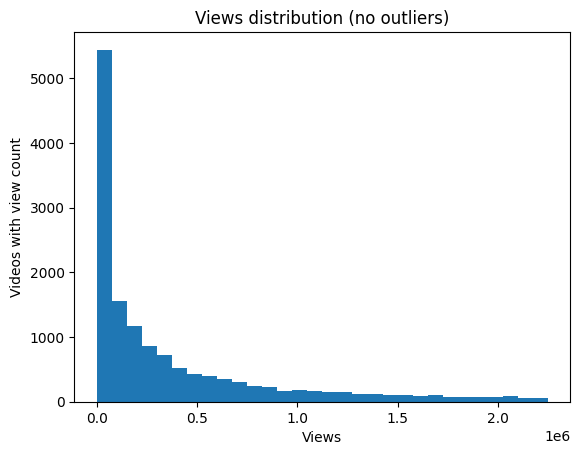

In [42]:
# Likes distribution (excluding outliers)
q75, q25 = np.percentile(yt_df['views'], [75, 25])
iqr = q75 - q25

print(q75, q25, iqr)
no_outliers = yt_df[yt_df['views'] < (q75 + iqr*1.5)]
no_outliers = no_outliers[no_outliers['views'] > (q25 - iqr*1.5)]

print(no_outliers['views'].max())

plt.hist(no_outliers['views'], bins=30)
plt.title("Views distribution (no outliers)")
plt.ylabel("Videos with view count")
plt.xlabel("Views")
plt.show()

In [ ]:
# YTDF without Null values (description bottleneck)
yt_clean = yt_df.dropna()
yt_clean.info()

<class 'pandas.DataFrame'>
Index: 13579 entries, 0 to 16399
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       13579 non-null  str  
 1   trending_date  13579 non-null  str  
 2   title          13579 non-null  str  
 3   channel_title  13579 non-null  str  
 4   views          13579 non-null  int64
 5   likes          13579 non-null  int64
 6   dislikes       13579 non-null  int64
 7   publish_time   13579 non-null  str  
 8   category_id    13579 non-null  int64
 9   tags           13579 non-null  str  
 10  comments       13579 non-null  int64
 11  channel_id     13579 non-null  str  
 12  description    13579 non-null  str  
dtypes: int64(5), str(8)
memory usage: 1.5 MB


In [50]:
yt_clean["combined_text"] = yt_clean["title"] + yt_clean["description"]

## Extract a vocabulary from the YouTube text data.
## No basic english words (and, it, the, he, she, etc.)
## n grams of up to two words allowed (2 words that are frequently associated with eachother. I.e. Artificially Intelligence)
## max and min data frequency defines the range of word frequencies allowed to appear in the vocab
## -   Adjusting these values can help capture popular topics and filter out uninformative words
vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), max_df = 0.02, min_df = 0.005)
text_vector = vectorizer.fit_transform(yt_clean["combined_text"])

vect_vocab = list(vectorizer.vocabulary_.keys())
print("Vocab size: ", len(vect_vocab))
print("Vocab sample: ", vect_vocab[0:20])


Vocab size:  2755
Vocab sample:  ['tried', 'gang', 'vonoff1700', 'official video', 'socials instagram', 'listen https', 'wait', 'arrives', 'imax', 'line', 'franchise', 'johnny', 'cage', 'ultimate', 'alongside', 'lord', 'joe', 'adventure', 'screenplay', 'created']


## WEL Fake News Dataset

In [69]:
fn_path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")

print("Path to fake news dataset files:", fn_path)

Path to fake news dataset files: C:\Users\sheic\.cache\kagglehub\datasets\nitaisatapathy\welfake-dataset\versions\1


In [70]:
## Import data and check for any critical null values (where both title + text are null, or label is null)
fn_df = pd.read_csv(fn_path+"/WELFake_Dataset.csv", index_col=0)
print(fn_df.head())
print(fn_df.info())
print("Fraction of null label values: ", fn_df['label'].isna().sum(), "/", len(fn_df['label']))

                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
<class 'pandas.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   71576 non-null  str  
 1   text    72095 non-null  str  
 2   label   72134 non-null  int64
dtypes: int64(1), s

Text(0.5, 0, 'Fake = 0, Real = 1')

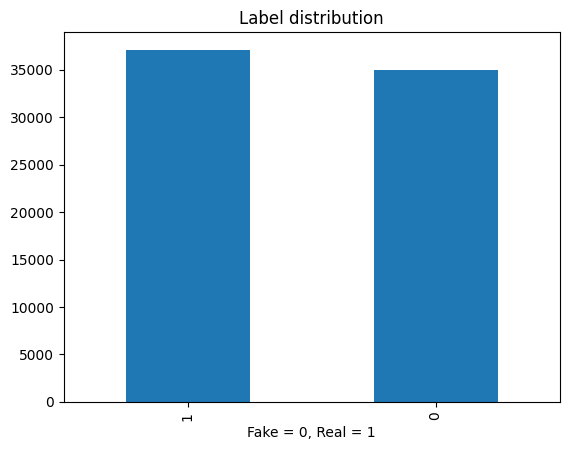

In [71]:
fn_df['label'].value_counts().plot(kind='bar')
plt.title("Label distribution")
plt.xlabel("Fake = 0, Real = 1")

In [80]:
fn_vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2), max_df = 0.02, min_df = 0.005)
fn_df["combined_text"] = fn_df["title"] + fn_df["text"]
fn_clean = fn_df.dropna(subset=["combined_text"])

fn_clean.head()
fn_vector = fn_vectorizer.fit_transform(fn_clean["combined_text"])
fn_vocab = list(fn_vectorizer.vocabulary_.keys())

print("Vocab sample: ", fn_vocab[:20])

Vocab sample:  ['alert', 'cops', 'whites', 'movements', 'hanging', 'encouraged', 'organizers', 'blog', 'hosted', '53', 'urging', 'tonight', 'dismantle', 'invite', 'aired', '00', '39', 'clip', 'unidentified', 'bunch']
